**Librerías**
-

In [456]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np 
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse

# **1. Lectura y Selección Variables Muestra**

## **1.1 Lectura Muestra**

In [457]:
data = pd.read_csv("../data/processed.csv")

data.head()

,Unnamed: 0,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,...,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,district_pickup,borough_dropoff,district_dropoff,distancia_haversine_km,velocidad_promedio_kmh
0,970802,id3561642,1,2016-03-12 18:25:05,2016-03-12 18:30:38,1,-73.987946,40.743935,-73.979248,40.752480,...,Saturday,18,Saturday,18,Manhattan,105,Manhattan,105,1.199834,12.971179
1,1190423,id3811637,2,2016-04-13 18:17:29,2016-04-13 18:40:49,1,-73.986748,40.755871,-73.949692,40.784519,...,Wednesday,18,Wednesday,18,Manhattan,105,Manhattan,108,4.459326,11.466837
2,538016,id1822735,1,2016-06-25 10:03:28,2016-06-25 10:08:40,1,-73.955673,40.779434,-73.971214,40.786018,...,Saturday,10,Saturday,10,Manhattan,108,Manhattan,107,1.499389,17.300644
3,436657,id2261569,2,2016-04-14 22:03:36,2016-04-14 22:08:34,6,-74.000984,40.731754,-73.991058,40.734970,...,Thursday,22,Thursday,22,Manhattan,102,Manhattan,105,0.909572,10.988118
4,912361,id3546531,1,2016-01-08 08:58:18,2016-01-08 09:11:17,1,-74.015892,40.711498,-74.002022,40.715237,...,Friday,8,Friday,9,Manhattan,101,Manhattan,101,1.240744,5.733860


## **1.2 Selección de Variables**

In [458]:
data.columns

Index(['Unnamed: 0', 'id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'dia_semana_pickup', 'horas_pickup',
       'dia_semana_dropoff', 'horas_dropoff', 'borough_pickup',
       'district_pickup', 'borough_dropoff', 'district_dropoff',
       'distancia_haversine_km', 'velocidad_promedio_kmh'],
      dtype='str')

**Observaciones**
- Unnamed, id, pickup_datetime, dropoff_datetime, pickup_longitude y dropoff_longitude no serán seleccionadas en el análisis, debido a que presentan información irrelevante o ya incluida en otras variables.

In [459]:
del_cols = [
    'Unnamed: 0', 'id', 'pickup_datetime', 'dropoff_datetime','pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude','district_pickup','district_dropoff'
]
df = data.drop(columns=del_cols)

**Observaciones**
- Para darle un mejor uso a las columnas de hora_pickup y hora_dropoff, se creará una columna que mida la franja horaria en la que sucedió el viaje.

In [460]:
bins = [-1, 5, 11, 17, 23]
labels = ["Madrugada", "Mañana", "Tarde", "Noche"]

df["franja_horaria_pickup"] = pd.cut(
    df["horas_pickup"],
    bins=bins,
    labels=labels
)

df["franja_horaria_dropoff"] = pd.cut(
    df["horas_dropoff"],
    bins=bins,
    labels=labels
)

# **2. Clusterización**

## **2.1 Selección Columnas**

In [461]:
cat_cols = [
    'borough_pickup','borough_dropoff','dia_semana_pickup',
    'dia_semana_dropoff', 'vendor_id', 'store_and_fwd_flag'
]

num_cols = [
    "distancia_haversine_km",
    'trip_duration', 'horas_pickup', 'horas_dropoff',
]

X = df[num_cols].copy()

## **2.2 Estandarización**

In [462]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## **2.3 Clusterización distintos k**

In [463]:
output_dir = "../output/role_2"
output_file = os.path.join(output_dir, "kmeans_results.csv")

if not os.path.exists(output_file):

    os.makedirs(output_dir, exist_ok=True)

    k_values = range(2, 15)

    inertias = []
    silhouette_scores = []
    davies_bouldin_scores = []
    calinski_harabasz_scores = []

    for k in k_values:

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(X_scaled)

        # Inercia
        inertias.append(kmeans.inertia_)

        # Silhouette
        silhouette_scores.append(
            silhouette_score(X_scaled, labels)
        )

        # Davies-Bouldin
        davies_bouldin_scores.append(
            davies_bouldin_score(X_scaled, labels)
        )

        # Calinski-Harabasz
        calinski_harabasz_scores.append(
            calinski_harabasz_score(X_scaled, labels)
        )

    results_kmeans = pd.DataFrame({
        "k": list(k_values),
        "inertia": inertias,
        "silhouette": silhouette_scores,
        "davies_bouldin": davies_bouldin_scores,
        "calinski_harabasz": calinski_harabasz_scores
    })

    results_kmeans.to_csv(output_file, index=False)

    print(f"Resultados calculados y guardados en: {output_file}")

else:

    results_kmeans = pd.read_csv(output_file)

    print(f"El archivo ya existe. Resultados cargados desde: {output_file}")

El archivo ya existe. Resultados cargados desde: ../output/role_2/kmeans_results.csv


In [464]:
results_kmeans

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,105028.962748,0.448753,0.917282,20934.530294
1,3,67119.077265,0.456170,0.633157,27674.384229
2,4,43246.747382,0.495800,0.594076,35992.409158
3,5,31285.219840,0.451190,0.627806,41137.274323
4,6,26624.835916,0.452261,0.726947,40069.628191
5,7,22226.711133,0.408516,0.749192,41316.584690
6,8,19091.416549,0.417817,0.714080,42167.245076
7,9,16996.911761,0.421232,0.669068,42058.204033
8,10,15095.052789,0.385655,0.712253,42653.992138
9,11,13685.435633,0.391299,0.715466,42753.486589


## **2.4 Visualización Métricas**

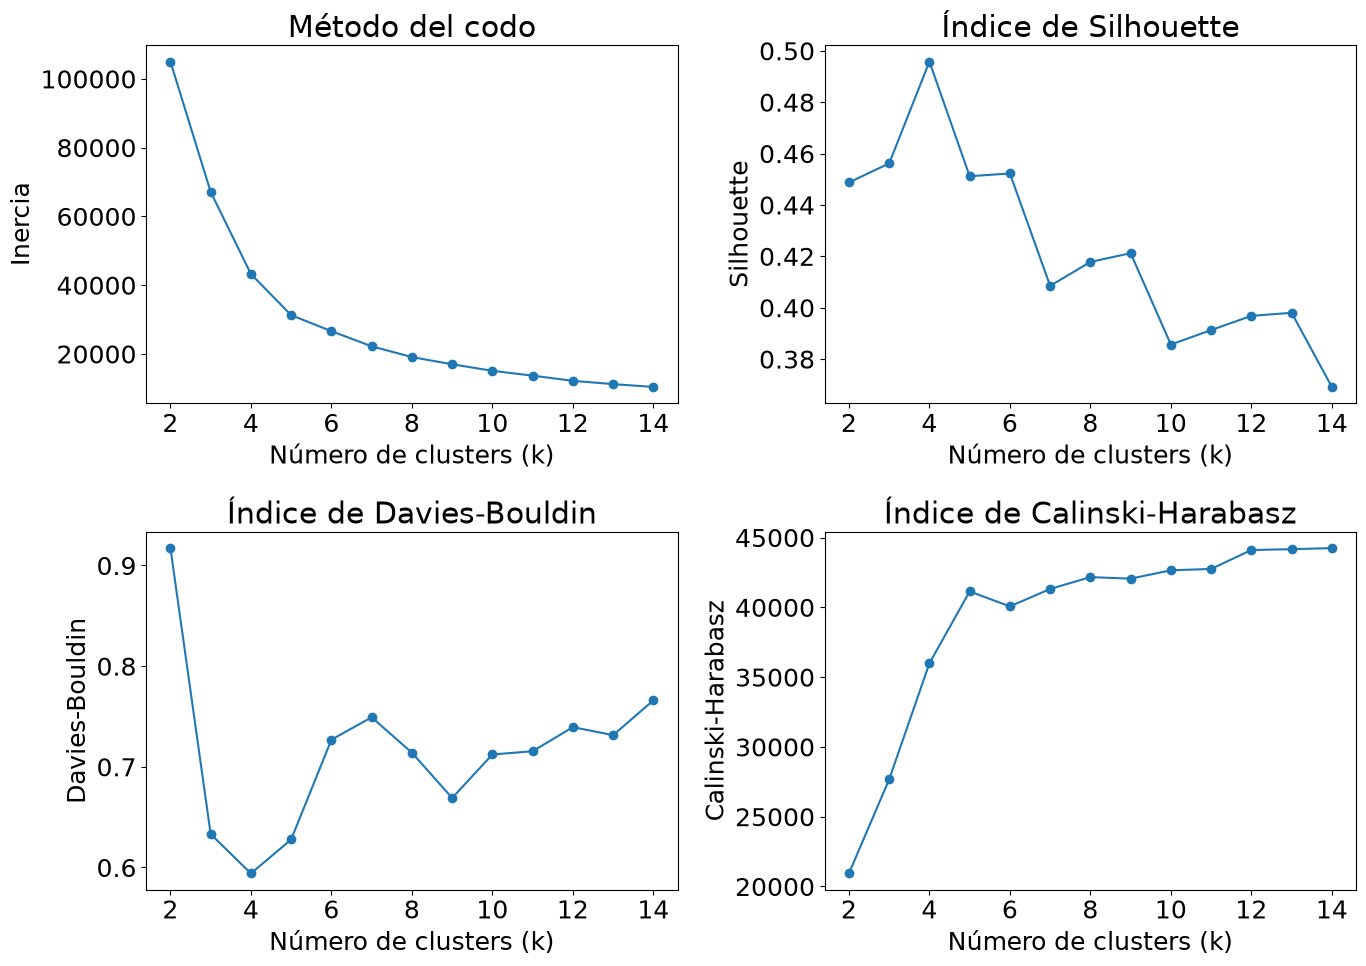

In [465]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Método del codo
axes[0, 0].plot(
    results_kmeans["k"],
    results_kmeans["inertia"],
    marker="o"
)
axes[0, 0].set_title("Método del codo")
axes[0, 0].set_xlabel("Número de clusters (k)")
axes[0, 0].set_ylabel("Inercia")

# Silhouette
axes[0, 1].plot(
    results_kmeans["k"],
    results_kmeans["silhouette"],
    marker="o"
)
axes[0, 1].set_title("Índice de Silhouette")
axes[0, 1].set_xlabel("Número de clusters (k)")
axes[0, 1].set_ylabel("Silhouette")

# Davies-Bouldin
axes[1, 0].plot(
    results_kmeans["k"],
    results_kmeans["davies_bouldin"],
    marker="o"
)
axes[1, 0].set_title("Índice de Davies-Bouldin")
axes[1, 0].set_xlabel("Número de clusters (k)")
axes[1, 0].set_ylabel("Davies-Bouldin")

# Calinski-Harabasz
axes[1, 1].plot(
    results_kmeans["k"],
    results_kmeans["calinski_harabasz"],
    marker="o"
)
axes[1, 1].set_title("Índice de Calinski-Harabasz")
axes[1, 1].set_xlabel("Número de clusters (k)")
axes[1, 1].set_ylabel("Calinski-Harabasz")

plt.tight_layout()
plt.show()

**Observaciones**
- A partir de las métricas analizadas, se considera que $k=4$ es una opción adecuada y coherente en la clusterización, debido a sus valores del índice de Silhouette y el índice de Davies-Bouldin presentan los mejores valores para los $k$ analizados.
- El valor del índice de Silhouette ($\approx 0.5$) expone una separación moderada entre clases, pero no completamente. 
- El valor del índice de Davies Bouldin ($\approx 0.6$) expresa una mejor separación y compactación de los clusteres frente a otros k.
- La inercia y el Calisnki-Harabasz presentan mejores valores a medida que aumentan los $k$, pero a su vez, disminuyen las métricas de Davies-Bouldin y Silhouette. No obstante, $k=4$ representa un mejor equilibrio en el desempeño de todas las métricas-

## **2.5 Análisis de Clústeres**

### **2.5.0 Implementación K-means con $k$ elegido**

In [466]:
def tabla_cont(df, c1, c2):
    tabla_contingencia = pd.crosstab(
        df[c1],
        df[c2]
    )
    return tabla_contingencia
def histograma_kde(df1, df2, columna, bins=30, percentil=100):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    datos1 = df1[columna].dropna()
    datos2 = df2[columna].dropna()

    # Percentil común calculado sobre ambos DataFrames
    if percentil < 100:
        p = pd.concat([datos1, datos2]).quantile(percentil / 100)

        datos1 = datos1[datos1 <= p]
        datos2 = datos2[datos2 <= p]

    # Límites comunes para los histogramas
    limites = np.histogram_bin_edges(
        pd.concat([datos1, datos2]),
        bins=bins
    )

    # ─────────────────────────
    # Gráfico 1: Histograma
    # ─────────────────────────
    axes[0].hist(
        datos1,
        bins=limites,
        alpha=0.5,
        edgecolor="black",
        label="Cluster"
    )

    axes[0].hist(
        datos2,
        bins=limites,
        alpha=0.5,
        edgecolor="black",
        label="Muestra"
    )

    axes[0].set_xlabel(columna)
    axes[0].set_ylabel("Densidad")
    axes[0].set_title(
        f"Histograma de densidad - {columna}"
        + (f" (P{percentil})" if percentil < 100 else "")
    )
    axes[0].legend()

    # ─────────────────────────
    # Gráfico 2: KDE
    # ─────────────────────────
    sns.kdeplot(
        datos1,
        ax=axes[1],
        fill=True,
        alpha=0.4,
        label="Cluster"
    )

    sns.kdeplot(
        datos2,
        ax=axes[1],
        fill=True,
        alpha=0.4,
        label="Muestra"
    )

    axes[1].set_xlabel(columna)
    axes[1].set_ylabel("Densidad")
    axes[1].set_title(
        f"KDE - {columna}"
        + (f" (P{percentil})" if percentil < 100 else "")
    )
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [467]:
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans_final.fit_predict(X_scaled)
df['k_mean_cluster'] = labels_kmeans

df.head()

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
0,1,1,N,5.550000,Saturday,18,Saturday,18,Manhattan,Manhattan,1.199834,12.971179,Noche,Noche,1
1,2,1,N,23.333333,Wednesday,18,Wednesday,18,Manhattan,Manhattan,4.459326,11.466837,Noche,Noche,1
2,1,1,N,5.200000,Saturday,10,Saturday,10,Manhattan,Manhattan,1.499389,17.300644,Mañana,Mañana,2
3,2,6,N,4.966667,Thursday,22,Thursday,22,Manhattan,Manhattan,0.909572,10.988118,Noche,Noche,1
4,1,1,N,12.983333,Friday,8,Friday,9,Manhattan,Manhattan,1.240744,5.733860,Mañana,Mañana,2


In [468]:
# Tamaño de cada cluster
tamaños = df["k_mean_cluster"].value_counts()

# Orden:
# 1. mayor
# 2. menor
# 3. segundo mayor
# 4. tercero mayor
orden = list(tamaños.sort_values(ascending=False).index)

orden_nuevo = [
    orden[0],  # mayor → 0
    orden[-1], # menor → 1
    orden[1],  # segundo mayor → 2
    orden[2]   # tercero mayor → 3
]

cluster_dict = {
    cluster: nuevo
    for nuevo, cluster in enumerate(orden_nuevo)
}

df["k_mean_cluster"] = df["k_mean_cluster"].map(cluster_dict)

### **2.5.1 Cluster 0**

#### **Filtración Registros Cluster**

In [469]:
df_km_c1 = df[df['k_mean_cluster'] == 0]
print("Tamaño Cluster: ", df_km_c1.shape[0])
print(f"Porcentaje del Total: {(df_km_c1.shape[0]/df.shape[0])*100:.2f}%")
df_km_c1.head()

Tamaño Cluster:  21340
Porcentaje del Total: 53.35%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
0,1,1,N,5.550000,Saturday,18,Saturday,18,Manhattan,Manhattan,1.199834,12.971179,Noche,Noche,0
1,2,1,N,23.333333,Wednesday,18,Wednesday,18,Manhattan,Manhattan,4.459326,11.466837,Noche,Noche,0
3,2,6,N,4.966667,Thursday,22,Thursday,22,Manhattan,Manhattan,0.909572,10.988118,Noche,Noche,0
10,2,1,N,22.683333,Thursday,16,Thursday,17,Manhattan,Manhattan,1.815972,4.803452,Tarde,Tarde,0
13,2,1,N,26.333333,Wednesday,19,Wednesday,20,Manhattan,Manhattan,3.618850,8.245480,Noche,Noche,0


**Observaciones**
- El tamaño del cluster ocupa más de la mitad de la muestra analizada.

#### **vendor_id**

In [470]:
df_km_c0['vendor_id'].value_counts()/df['vendor_id'].value_counts()

vendor_id
2    0.072419
1    0.065087
Name: count, dtype: float64

**Observaciones**
- El cluster abarca el 53 % de los viajes con id_vendor = 1 y el 53% de los viajes con id_vendor = 2.

#### **dia_semana**

In [471]:
tabla_cont(df_km_c0,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,410,0,15,0,0,0,0
Monday,0,393,0,0,0,13,0
Saturday,0,0,283,8,0,0,0
Sunday,0,6,0,417,0,0,0
Thursday,16,0,0,0,389,0,0
Tuesday,0,0,0,0,0,396,13
Wednesday,0,0,0,0,22,0,379


In [472]:
tabla_cont(df,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


**Observaciones**
- El cluster representa por lo menos la mitad de los viajes que sucenden en un mismo día.
- El cluster no presenta viajes de múltiples días.

#### **borough**

In [473]:
tabla_cont(df_km_c0,"borough_pickup","borough_dropoff")

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,0,0,0,3,2,0
Brooklyn,2,4,0,18,18,0
Externo,0,0,0,1,1,0
Manhattan,125,165,80,225,721,6
Queens,20,275,29,950,112,3


In [474]:
tabla_cont(df,"borough_pickup","borough_dropoff")

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- El cluster logra captar más de la mitad de los viajes Manhattan-Manhattan y poco menos de la mitad de los viajes Manhattan-Brooklyn.

#### **store_and_fwd_flag**

In [475]:
df_km_c0['store_and_fwd_flag'].value_counts()/df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    0.068447
Y    0.163793
Name: count, dtype: float64

**Observaciones**
- El cluster abarca alrededor de la mitad de los casos en los que no se confirmo que el registro se había enviado al servidor

#### **franja horaria**

In [476]:
tabla_cont(df_km_c0,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,220,35,0,0
Mañana,0,496,82,0
Tarde,2,0,888,164
Noche,91,0,0,782


In [477]:
tabla_cont(df,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,4679,100,1,1
Mañana,0,9375,485,0
Tarde,3,0,11081,586
Noche,393,0,1,13295


**Observaciones**
- La mayoria de los viajes que suceden en el clusterestan en la franja tarde-tarde y noche-noche. 
- La franja noche-noche del cluster representa el 94% aproximadamente de la clase noche-noche de la muestra.
- La franja tarde-noche del cluster representa el 80% de los viajes de tarde-noche de la muestra.
- La franja tarde-tarde del cluster representa el 76% de los viajes tarde-tarde de la muestra.

#### **passenger_count**

In [478]:
df_km_c0['passenger_count'].value_counts()

passenger_count
1    1870
2     449
5     170
3     119
6      91
4      61
Name: count, dtype: int64

In [479]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

**Observaciones**
- El cluster representa al menos la mitad de los viajes de la muestra para cada número de pasajeros.

#### **distancia_harvesine**

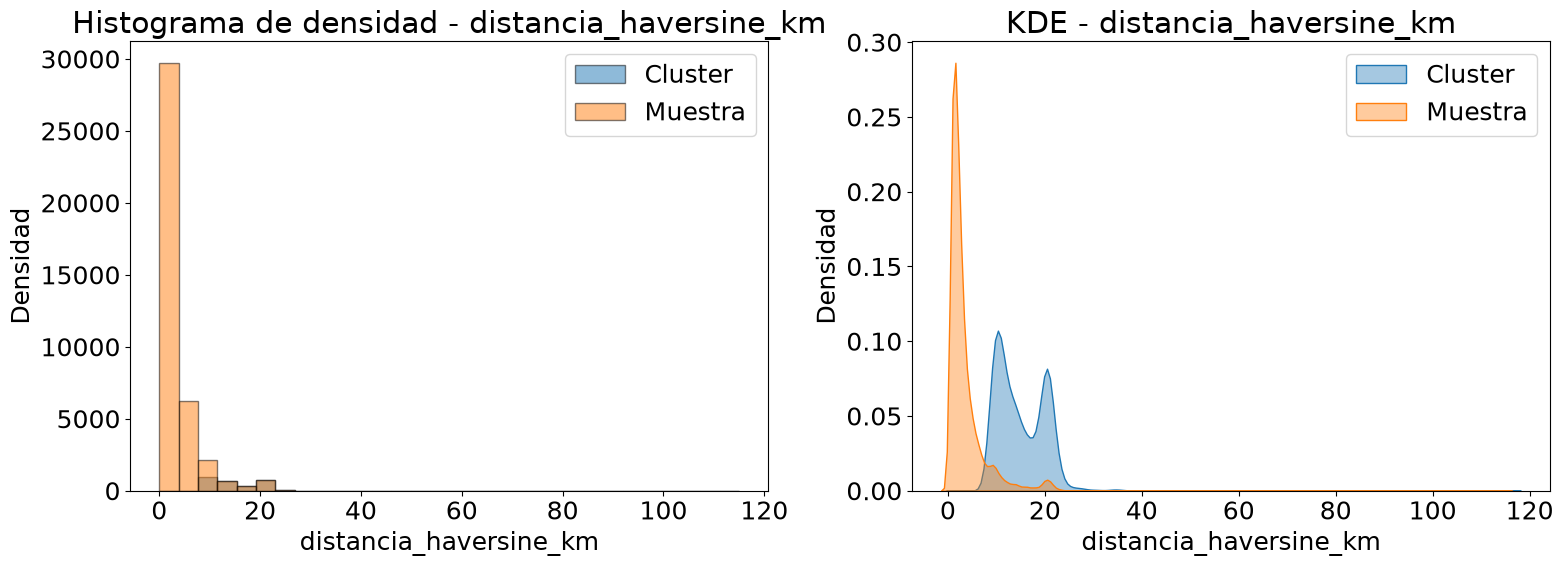

In [480]:
histograma_kde(df_km_c0,df,'distancia_haversine_km')

**Observaciones**
- El cluster abarca en su mayoría los viajes que poseen distancias inferiores a los 11km de la distancia haversine.

#### **velocidad_promedio_kmh**

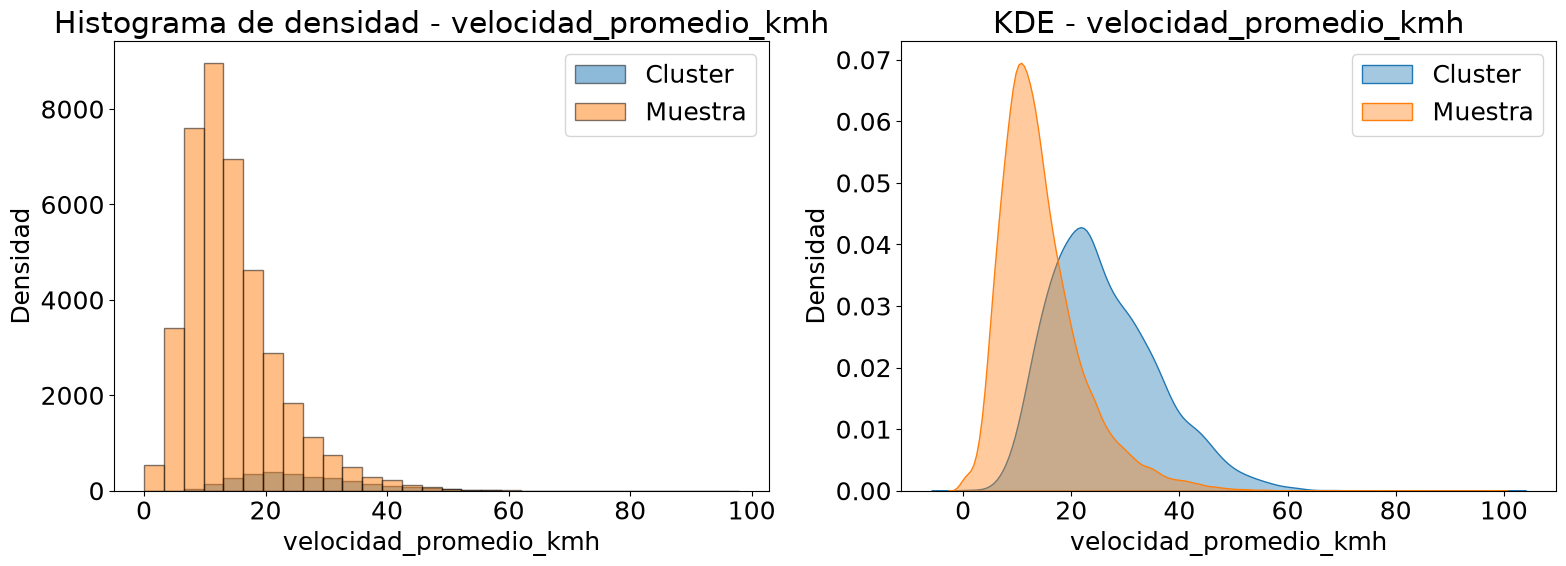

In [481]:
histograma_kde(df_km_c0,df,'velocidad_promedio_kmh')

**Observaciones**
- El cluster suele excluir varios viajes con velocidades promedio mayores a 18-20 aproximadamente.

#### **trip_duration**

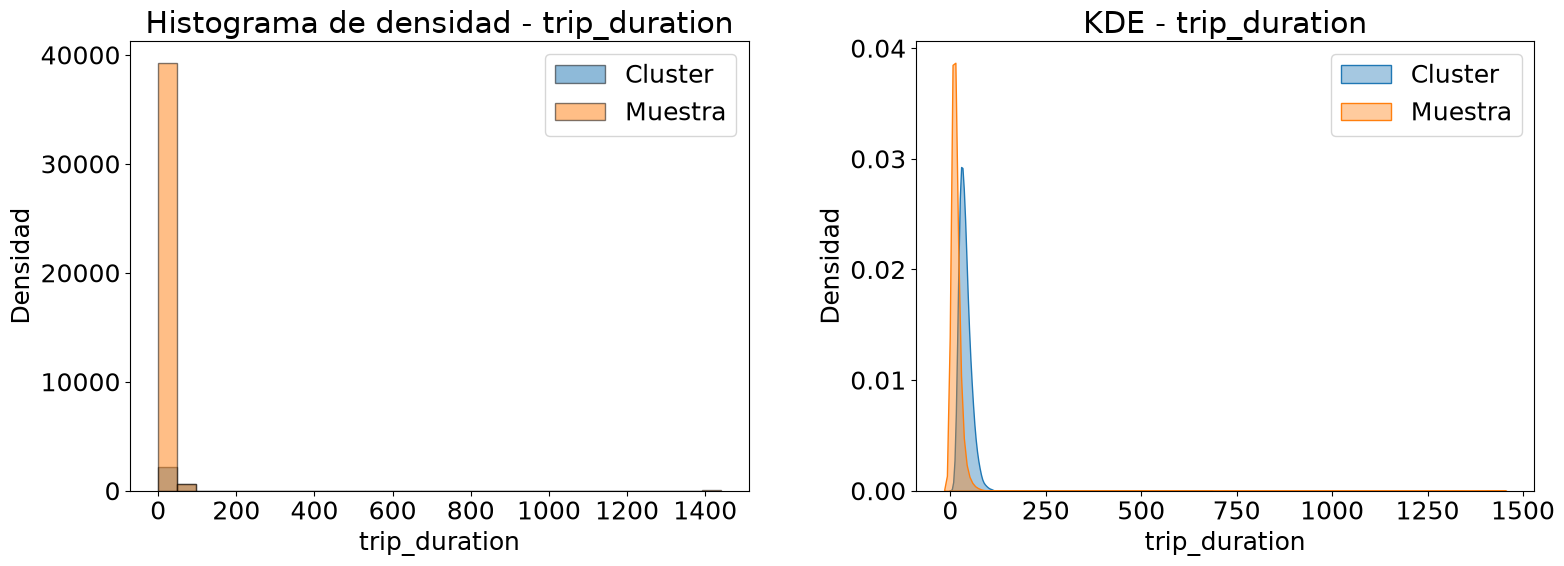

In [482]:
histograma_kde(df_km_c0,df,'trip_duration')

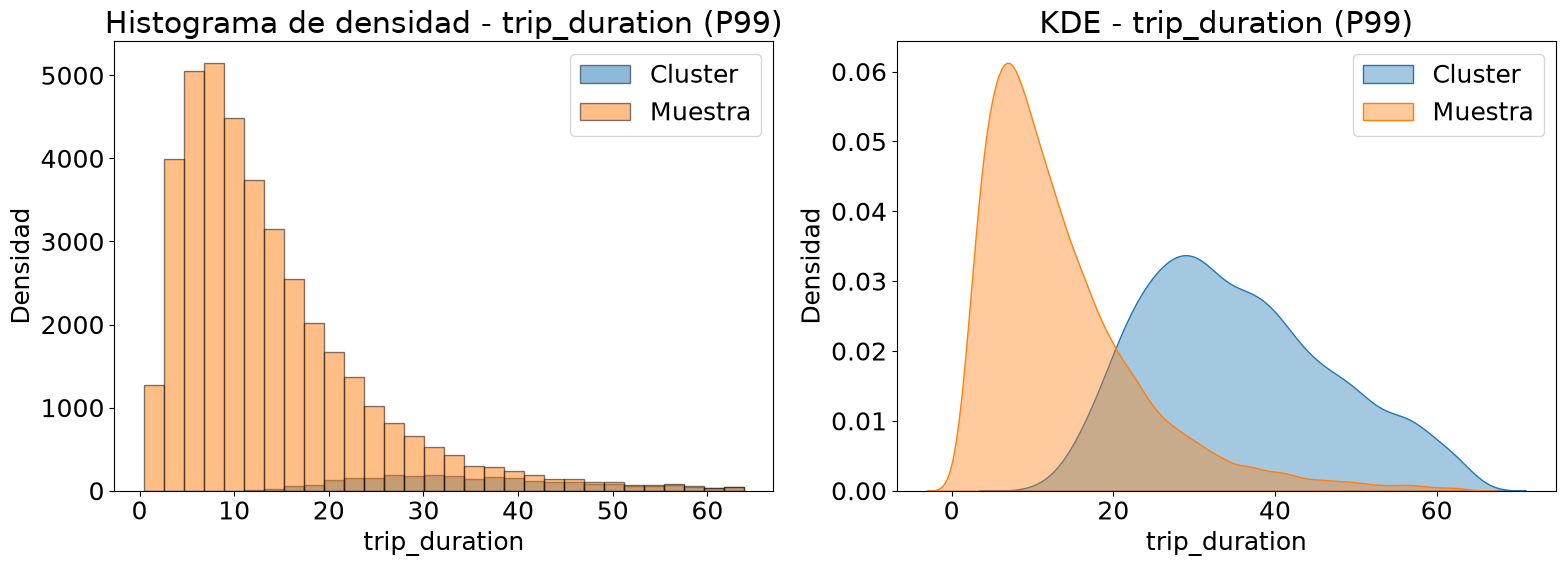

In [483]:
histograma_kde(df_km_c0,df,'trip_duration',30,99)

**Observaciones**
- El cluster excluye varios viajes que poseen duración mayor a 22-23 min aproximadamente.
- Dentro del cluster existen duraciones extremas.

In [484]:
df_km_c0[df_km_c0['trip_duration'] > 120]

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
10518,2,1,N,673.316667,Sunday,12,Monday,0,Manhattan,Queens,20.467905,1.823918,Tarde,Madrugada,0
26478,2,5,N,582.000000,Tuesday,14,Wednesday,0,Manhattan,Manhattan,2.778798,0.286474,Tarde,Madrugada,0


### **2.5.2 Cluster 1**

#### **Filtración de Viajes**

In [485]:
df_km_c1 = df[df['k_mean_cluster'] == 1]
print("Tamaño Cluster: ", df_km_c1.shape[0])
print(f"Porcentaje del Total: {(df_km_c1.shape[0]/df.shape[0])*100:.2f}%")
df_km_c1.head()

Tamaño Cluster:  42
Porcentaje del Total: 0.10%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
2882,2,2,N,1416.866667,Thursday,23,Friday,23,Manhattan,Manhattan,1.339752,0.056734,Noche,Noche,1
3090,2,1,N,1438.783333,Thursday,11,Friday,11,Manhattan,Manhattan,5.427887,0.226353,Mañana,Mañana,1
4831,2,1,N,1333.233333,Tuesday,9,Wednesday,7,Queens,Manhattan,3.355197,0.150995,Mañana,Mañana,1
5000,2,5,N,1429.716667,Thursday,11,Friday,11,Manhattan,Manhattan,1.767160,0.074161,Mañana,Mañana,1
5133,2,1,N,1386.166667,Saturday,23,Sunday,22,Manhattan,Manhattan,2.088489,0.090400,Noche,Noche,1


**Observaciones**
- El cluster abarca una porción casi insignificante de los datos, se especula que pueden ser viajes anómalos.

#### **vendor_id**

In [486]:
df_km_c1['vendor_id'].value_counts()

vendor_id
2    41
1     1
Name: count, dtype: int64

**Observaciones**
- El cluster solo registra viajes del vendedor 2.

#### **dia_semana**

In [487]:
tabla_cont(df_km_c1,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,0,0,6,0,0,0,0
Monday,0,0,0,0,0,4,0
Saturday,0,0,1,9,0,0,0
Sunday,0,4,0,0,0,0,0
Thursday,10,0,0,0,0,0,0
Tuesday,0,0,0,0,0,0,4
Wednesday,0,0,0,0,3,0,1


In [488]:
tabla_cont(df,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


**Observaciones**
- La mayor parte de los viajes del cluster suelen abarcar dos días.

#### **borough**

In [489]:
tabla_cont(df_km_c1,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens
borough_pickup,,,,,
Bronx,1,0,0,0,0
Brooklyn,0,1,0,0,0
Manhattan,0,1,1,32,3
Queens,0,0,0,3,0


In [490]:
tabla_cont(df,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- La mayor cantidad de los viajes del cluster son Manhattan-Manhattan.

#### **store_and_fwd_flag**

In [491]:
df_km_c1['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    42
Name: count, dtype: int64

**Observaciones**
- Ningún viaje del cluster se almaceno localmente antes de enviarse al servidor.

#### **franja_horaria**

**Observaciones**
- No se toma en cuenta franja horaria, porque varios viajes duraron más de un día. Por consiguiente, el análisis de la franja horaria no brindaría información completamente objetiva.

#### **passenger_count**

In [492]:
df_km_c1['passenger_count'].value_counts()

passenger_count
1    30
2     6
5     4
3     1
6     1
Name: count, dtype: int64

In [493]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

**Observaciones**
- La mayoría de los viajes del cluster tienen un pasajero.

#### **distancia_haversine**

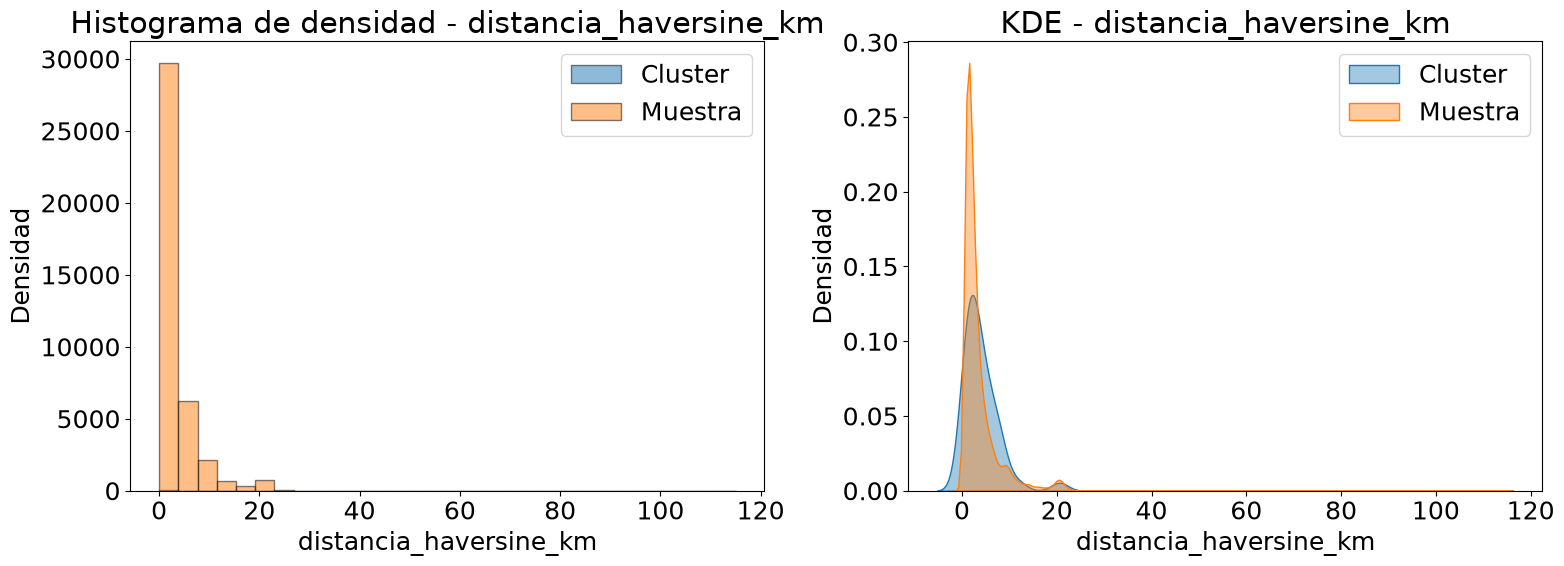

In [494]:
histograma_kde(df_km_c1,df,'distancia_haversine_km')

**Observaciones**
- El cluster suele evidenciar ciertas distancias extremas, aunque la mayor parte de sus observaciones posean distancias similares a las de la mayoría de observaciones de la muestra analizada.

#### **velocidad_promedio_kmh**

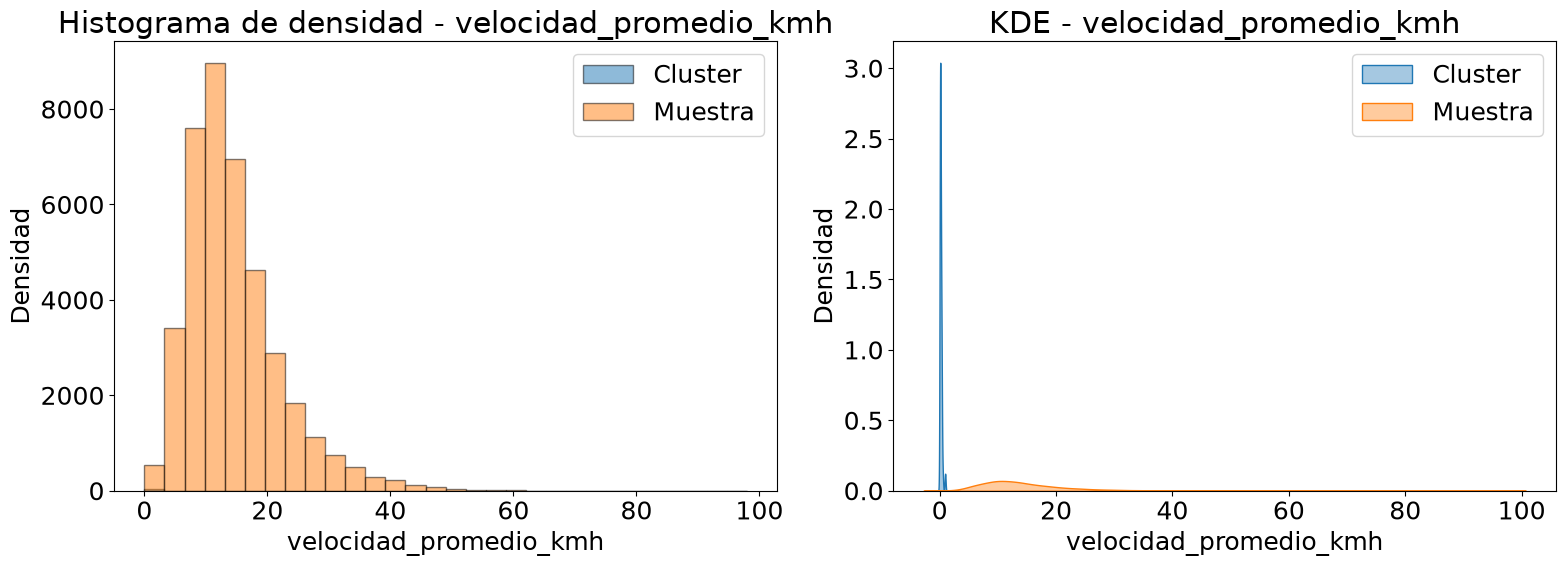

In [495]:
histograma_kde(df_km_c1,df,'velocidad_promedio_kmh')

**Observaciones**
- La velocidad promedio de los viajes del cluster es muy cercana a cero, esto difiere en gran manera de la distribución general.
- Es importante recordar que la velocidad promedio se definio como distancia/tiempo, por lo que no implica que el carro estuviera moviendose a una velocidad tan baja, sino que se demoro mucho tiempo en completar el viaje.

#### **trip_duration**

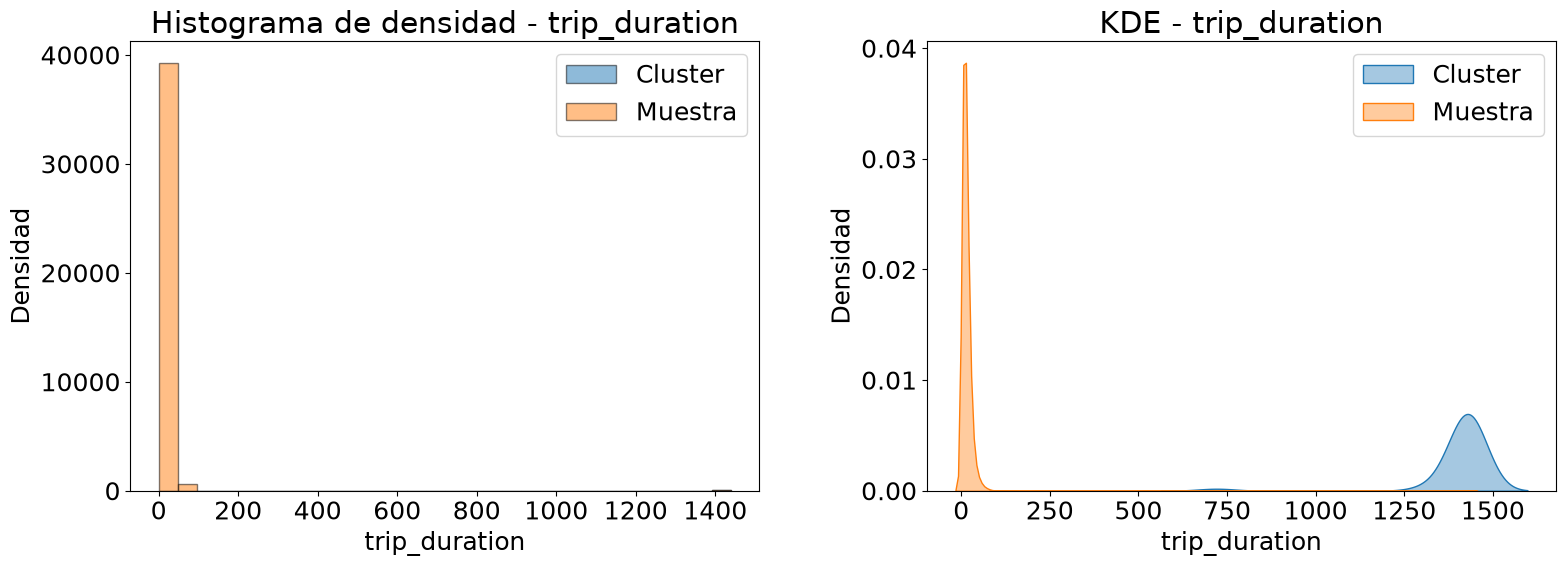

In [496]:
histograma_kde(df_km_c1,df,'trip_duration')

**Observaciones**
- Los viajes del cluster se caracterizan por tener tiempos de duración de viaje extremadamente elevados en contraste a los de la muestra en general.

### **2.5.3 Cluster 2**

#### **Filtración Viajes del Cluster**

In [497]:
df_km_c2 = df[df['k_mean_cluster'] == 2]
print("Tamaño Cluster: ", df_km_c2.shape[0])
print(f"Porcentaje del Total: {(df_km_c2.shape[0]/df.shape[0])*100:.2f}%")
df_km_c2.head()

Tamaño Cluster:  15858
Porcentaje del Total: 39.65%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
2,1,1,N,5.200000,Saturday,10,Saturday,10,Manhattan,Manhattan,1.499389,17.300644,Mañana,Mañana,2
4,1,1,N,12.983333,Friday,8,Friday,9,Manhattan,Manhattan,1.240744,5.733860,Mañana,Mañana,2
5,1,1,N,3.983333,Wednesday,6,Wednesday,6,Manhattan,Manhattan,0.803794,12.107363,Mañana,Mañana,2
6,1,1,N,9.433333,Thursday,7,Thursday,7,Manhattan,Manhattan,1.874589,11.923179,Mañana,Mañana,2
7,1,1,N,18.200000,Monday,10,Monday,10,Manhattan,Manhattan,3.976712,13.110039,Mañana,Mañana,2


#### **vendor_id**

In [498]:
df_km_c2['vendor_id'].value_counts()/df['vendor_id'].value_counts()

vendor_id
2    0.389732
1    0.404139
Name: count, dtype: float64

**Observaciones**
- El cluster 2 posee el 39% de los viajes que tienen el proveedor 2 y el 40% aproximadamente de los viajes que posee el proveedor 1.

#### **dia_semana**

In [499]:
tabla_cont(df_km_c2,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,2428,0,74,0,0,0,0
Monday,0,1909,0,0,0,28,0
Saturday,0,0,2394,67,0,0,0
Sunday,0,21,0,2403,0,0,0
Thursday,50,0,0,0,2192,0,0
Tuesday,0,0,0,0,0,2062,27
Wednesday,0,0,0,0,36,0,2167


In [500]:
tabla_cont(df,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


**Observaciones**
- A diferencia del Cluster 0, el Cluster 2 presenta viajes que abarcaron dos días distintos.
- El cluster 2 abarca una proporción significativa de viajes que sucedieron en el mismo dia, pero no tantos como el Cluster 1.

#### **borough**

In [501]:
tabla_cont(df_km_c2,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens
borough_pickup,,,,,
Bronx,10,0,0,5,0
Brooklyn,0,230,0,139,11
Externo,0,0,5,4,0
Manhattan,64,547,16,13926,465
Queens,6,32,2,167,229


In [502]:
tabla_cont(df,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- El cluster 2 abarca una parte importante de los viajes que se inician en Manhattan y terminan en Bronx, Brooklyn, Manhattan o Queens, aunque el cluster 0 posee una mayor proporción en estos.
- El cluster 2 abarca casi la mitad o más de la mitad de los viajes que inician en Brooklyn.

#### **stora_and_fwd_flag**

In [503]:
df_km_c2['store_and_fwd_flag'].value_counts()/df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    0.396701
Y    0.353448
Name: count, dtype: float64

**Observaciones**
- El cluster 2 abarca aproximadamente el 40% de todos los viajes que no se registraron localmente previo a ser enviados al servidor y el 34% de todos los viajes que si fueron registrados localmente antes de ser enviados.

#### **franja_horaria**

In [504]:
tabla_cont(df_km_c2,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde
franja_horaria_pickup,,,
Madrugada,4452,65,0
Mañana,0,8872,403
Tarde,1,0,1763
Noche,302,0,0


In [505]:
tabla_cont(df,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,4679,100,1,1
Mañana,0,9375,485,0
Tarde,3,0,11081,586
Noche,393,0,1,13295


**Observaciones**
- El cluster 2 abarca la mayor proporción de los viajes de las franjas madrugada-madrugada y mañana-mañana, mientras que no posee ningún registro en la franja Noche-Noche. De este modo, se evidencia que los viajes del cluster que iniciaron en la noche no son finalizados sino hasta la madrugada.
- El cluster dos posee una cantidad pequeña (pero no insignificante) de viajes en la franja horaria tarde-tarde en contraste al cluster 0

#### **passanger_count**

In [506]:
df_km_c2['passenger_count'].value_counts()

passenger_count
1    11665
2     2010
5      822
3      606
6      493
4      262
Name: count, dtype: int64

In [507]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

**Observaciones**
- El cluster 2 posee poco más de 1/3 de los viajes para cada número de pasajeros.

#### **distancia_haversine_km**

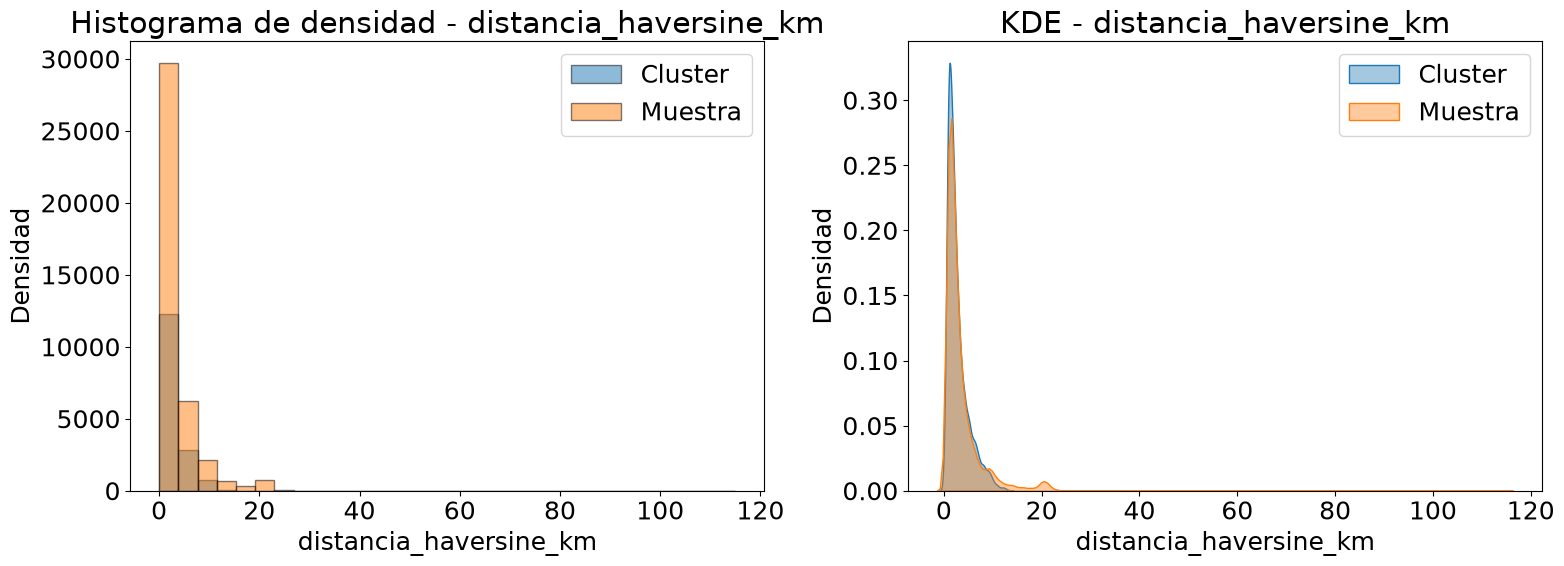

In [508]:
histograma_kde(df_km_c2,df,'distancia_haversine_km')

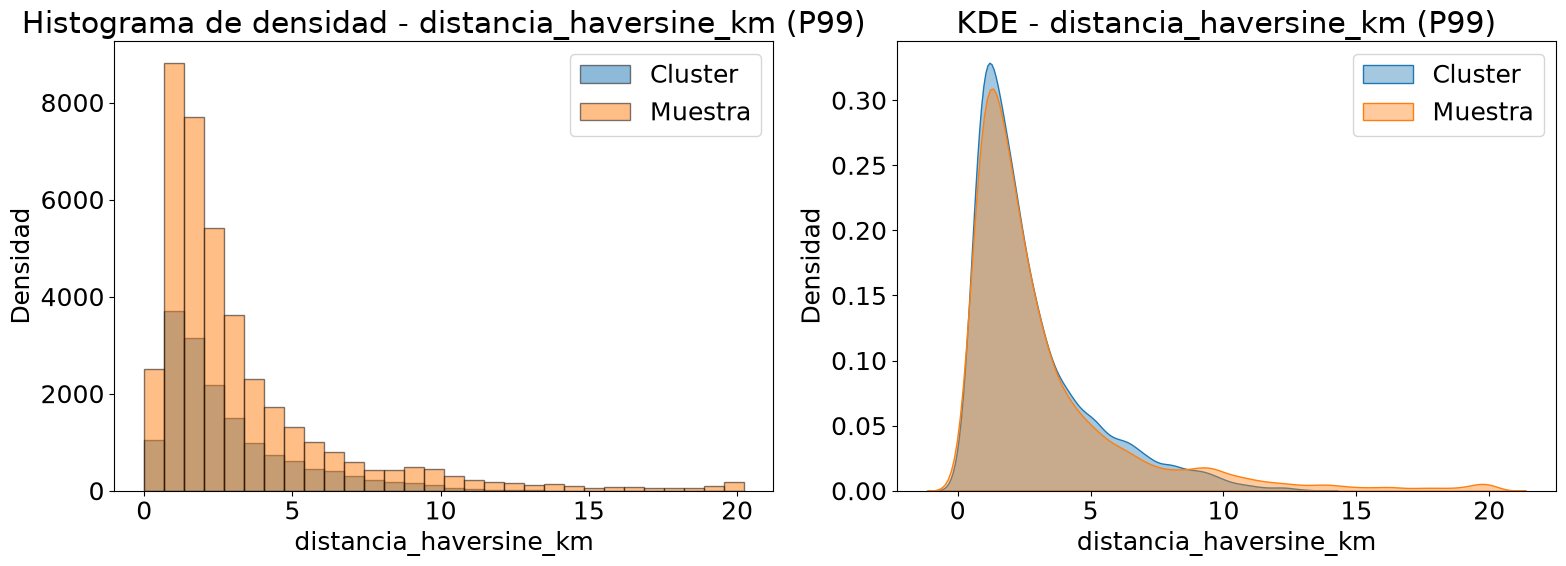

In [509]:
histograma_kde(df_km_c2,df,'distancia_haversine_km',30,99)

In [510]:
df_km_c2[df_km_c2['distancia_haversine_km'] >14]

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster


**Observaciones**
- La mayor cantidad de distancias en el cluster 2 siguen de forma similar la distribución de la muestra analizada, quitando los atípicos de la muestra, donde el cluster 2 no posee distancias mayores a 14km.

#### **velocidad_promedio_kmh**

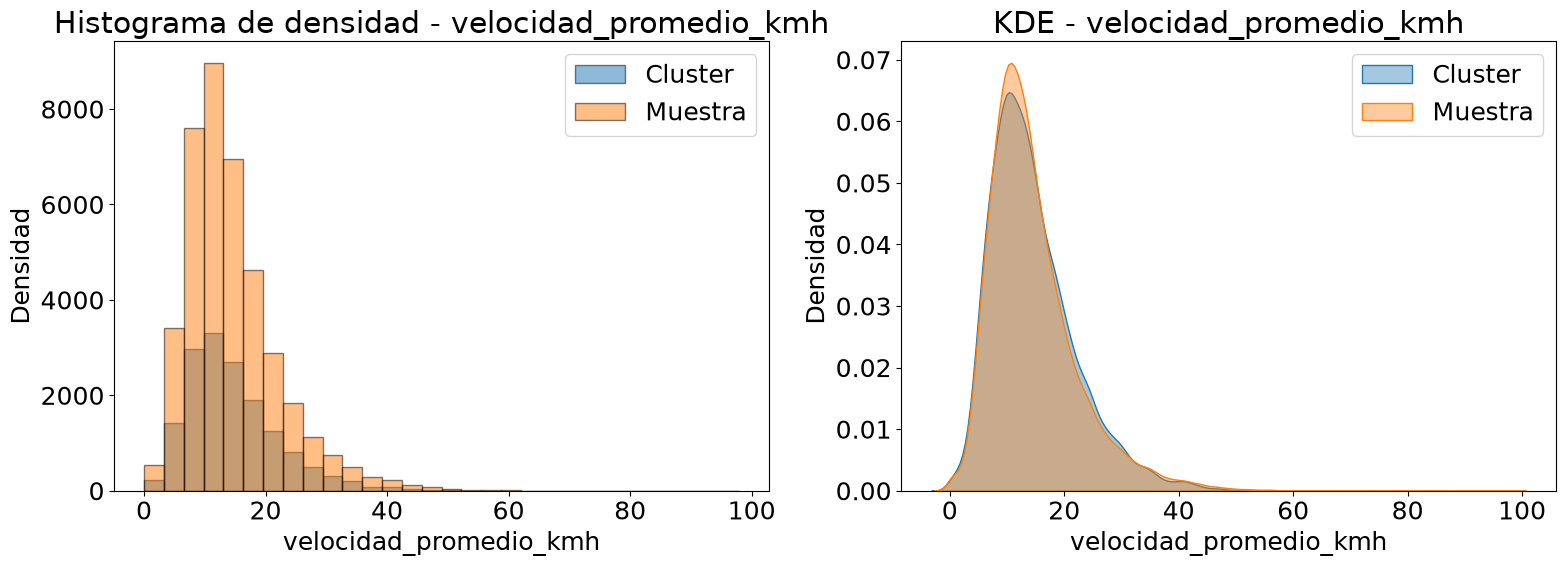

In [511]:
histograma_kde(df_km_c2,df,'velocidad_promedio_kmh')

In [512]:
df_km_c2[df_km_c2['velocidad_promedio_kmh'] > 60]

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
2573,1,1,N,1.366667,Wednesday,5,Wednesday,5,Externo,Externo,1.659864,72.872093,Madrugada,Madrugada,2
9795,1,1,N,2.800000,Sunday,4,Sunday,5,Manhattan,Brooklyn,2.803418,60.073250,Madrugada,Madrugada,2
14877,2,6,N,0.566667,Monday,5,Monday,5,Manhattan,Manhattan,0.788573,83.495913,Madrugada,Madrugada,2
36449,1,1,N,9.716667,Saturday,2,Saturday,2,Manhattan,Manhattan,10.356593,63.951517,Madrugada,Madrugada,2


**Observaciones**
- La distribución de velocidades promedio dentro del cluster peresenta el mismo sesgo positivo que la muestra analizada.

#### **trip_duration**

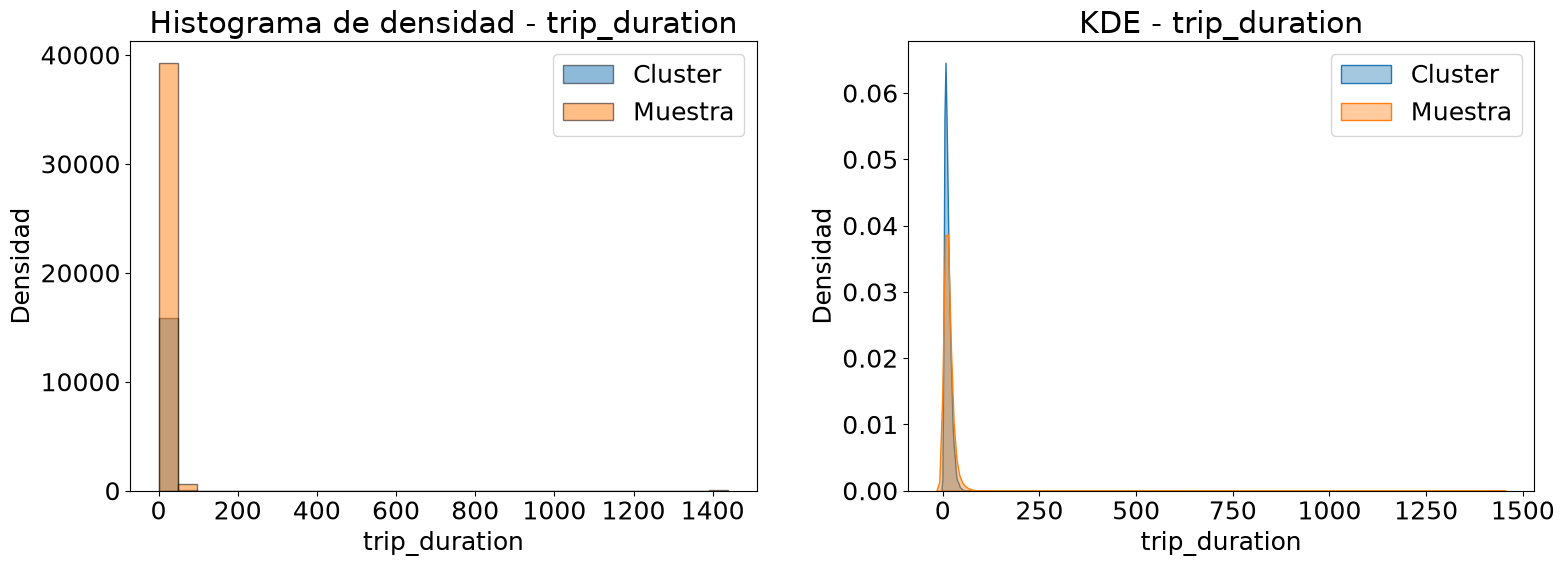

In [513]:
histograma_kde(df_km_c2,df,'trip_duration')

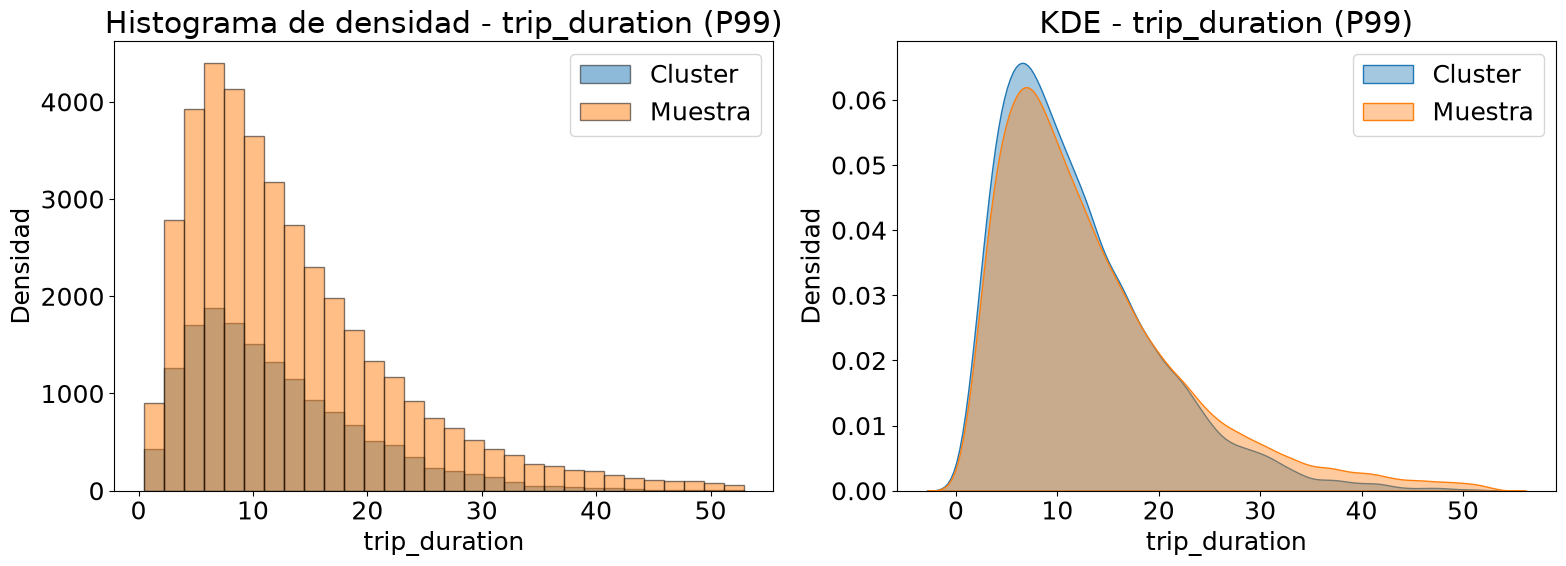

In [514]:
histograma_kde(df_km_c2,df,'trip_duration',30,99)

In [515]:
df_km_c2[df_km_c2['trip_duration'] > 120]

,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
2658,1,1,N,146.466667,Friday,3,Friday,5,Manhattan,Bronx,7.874975,3.225980,Madrugada,Madrugada,2
17637,2,1,N,215.150000,Monday,20,Tuesday,0,Manhattan,Manhattan,4.685589,1.306695,Noche,Madrugada,2
28254,2,1,N,518.316667,Monday,15,Tuesday,0,Manhattan,Manhattan,1.287576,0.149049,Tarde,Madrugada,2


**Observaciones**
- El cluster 2 presenta un sesgo positivo tal como lo presenta la totalidad de la muestra analizada.

### **2.5.4 Cluster 3**

#### **Filtración de Viajes dentro del Cluster**

In [520]:
df_km_c3 = df[df['k_mean_cluster'] == 3]
print("Tamaño Cluster: ", df_km_c3.shape[0])
print(f"Porcentaje del Total: {(df_km_c3.shape[0]/df.shape[0])*100:.2f}%")
df_km_c3.head()

Tamaño Cluster:  2760
Porcentaje del Total: 6.90%


,vendor_id,passenger_count,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,borough_dropoff,distancia_haversine_km,velocidad_promedio_kmh,franja_horaria_pickup,franja_horaria_dropoff,k_mean_cluster
29,1,2,N,47.600000,Thursday,10,Thursday,11,Queens,Manhattan,9.386598,11.831846,Mañana,Mañana,3
37,1,1,N,35.200000,Tuesday,20,Tuesday,20,Manhattan,Brooklyn,9.784537,16.678187,Noche,Noche,3
43,1,1,N,32.500000,Wednesday,12,Wednesday,12,Manhattan,Queens,11.087168,20.468617,Tarde,Tarde,3
55,1,1,N,37.733333,Sunday,10,Sunday,11,Manhattan,Brooklyn,12.829537,20.400324,Mañana,Mañana,3
60,2,2,N,29.050000,Tuesday,23,Wednesday,0,Queens,Brooklyn,14.320446,29.577513,Noche,Madrugada,3


**Observaciones**
- El cluster 3 es relativamente pequeño. Los más grandes son el cluster 0 (53%) y 1 (40%).

#### **id_vendor**

In [524]:
df_km_c3['vendor_id'].value_counts()/df['vendor_id'].value_counts()

vendor_id
2    0.072419
1    0.065087
Name: count, dtype: float64

**Observaciones**
- El cluster 3 evidencia un 7.2% de los viajes que poseen el proveedor 2 y un 6.5% de los viajes del proveedor 1.

#### **dia_semana**

In [525]:
tabla_cont(df_km_c3,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,410,0,15,0,0,0,0
Monday,0,393,0,0,0,13,0
Saturday,0,0,283,8,0,0,0
Sunday,0,6,0,417,0,0,0
Thursday,16,0,0,0,389,0,0
Tuesday,0,0,0,0,0,396,13
Wednesday,0,0,0,0,22,0,379


In [526]:
tabla_cont(df,'dia_semana_pickup','dia_semana_dropoff')

dia_semana_dropoff,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
dia_semana_pickup,,,,,,,
Friday,6036,0,95,0,0,0,0
Monday,0,5217,0,0,0,45,0
Saturday,0,0,6008,84,0,0,0
Sunday,0,31,0,5348,0,0,0
Thursday,76,0,0,0,5821,0,0
Tuesday,0,0,0,0,0,5473,44
Wednesday,0,0,0,0,61,0,5661


**Observaciones**
- El cluster 3 presenta una combinación de viajes que abarcaron un día y también dos días.

#### **borough**

In [517]:
tabla_cont(df_km_c3,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,0,0,0,3,2,0
Brooklyn,2,4,0,18,18,0
Externo,0,0,0,1,1,0
Manhattan,125,165,80,225,721,6
Queens,20,275,29,950,112,3


In [527]:
tabla_cont(df,'borough_pickup','borough_dropoff')

borough_dropoff,Bronx,Brooklyn,Externo,Manhattan,Queens,Staten Island
borough_pickup,,,,,,
Bronx,19,0,0,16,2,0
Brooklyn,2,448,0,222,35,0
Externo,0,1,11,9,1,0
Manhattan,229,1331,109,33804,1450,6
Queens,33,332,36,1332,569,3


**Observaciones**
- El cluster 3 abarca una porción grande de los viajes que inician en Queens y terminan en un lugar distinto a este lugar. Además, evidencia la mayor cantidad de viajes que finalizaron en un lugar externo a los municipios analizados.

#### **store_and_fwd_flag**

In [528]:
df_km_c3['store_and_fwd_flag'].value_counts()/df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    0.068447
Y    0.163793
Name: count, dtype: float64

In [531]:
df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    39768
Y      232
Name: count, dtype: int64

In [530]:
df_km_c3['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    2722
Y      38
Name: count, dtype: int64

**Observaciones**
- El cluster 3 evidencia una proporción pequeña del total de viajes no fueron almacenados localmente antes de ser enviados al servidor. No obstante, posee alrededor del 16% (38 registros) de los que si fueron almacenados localmente.

#### **franja_horaria**

In [532]:
tabla_cont(df_km_c3,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,220,35,0,0
Mañana,0,496,82,0
Tarde,2,0,888,164
Noche,91,0,0,782


In [533]:
tabla_cont(df,'franja_horaria_pickup','franja_horaria_dropoff')

franja_horaria_dropoff,Madrugada,Mañana,Tarde,Noche
franja_horaria_pickup,,,,
Madrugada,4679,100,1,1
Mañana,0,9375,485,0
Tarde,3,0,11081,586
Noche,393,0,1,13295


**Observaciones**
- Los viajes del cluster 3 suelen presentar en una pequeña parte la distribución de las franjas horarias de la muestra en general.
- En el cluster 3 se evidencian 2 de los 3 viajes que sucedieron desde la tarde hasta la madrugada.

#### **passenger_count**

In [535]:
df_km_c3['passenger_count'].value_counts()

passenger_count
1    1870
2     449
5     170
3     119
6      91
4      61
Name: count, dtype: int64

In [ ]:
df['passenger_count'].value_counts()

passenger_count
1    28399
2     5733
5     2170
3     1671
6     1256
4      771
Name: count, dtype: int64

**Observaciones**
- El número de pasajeros no es un aspecto que diferencie al cluster, se observa que conserva el mismo orden de magnitud en la variable.

#### **distancia_haversine_km**

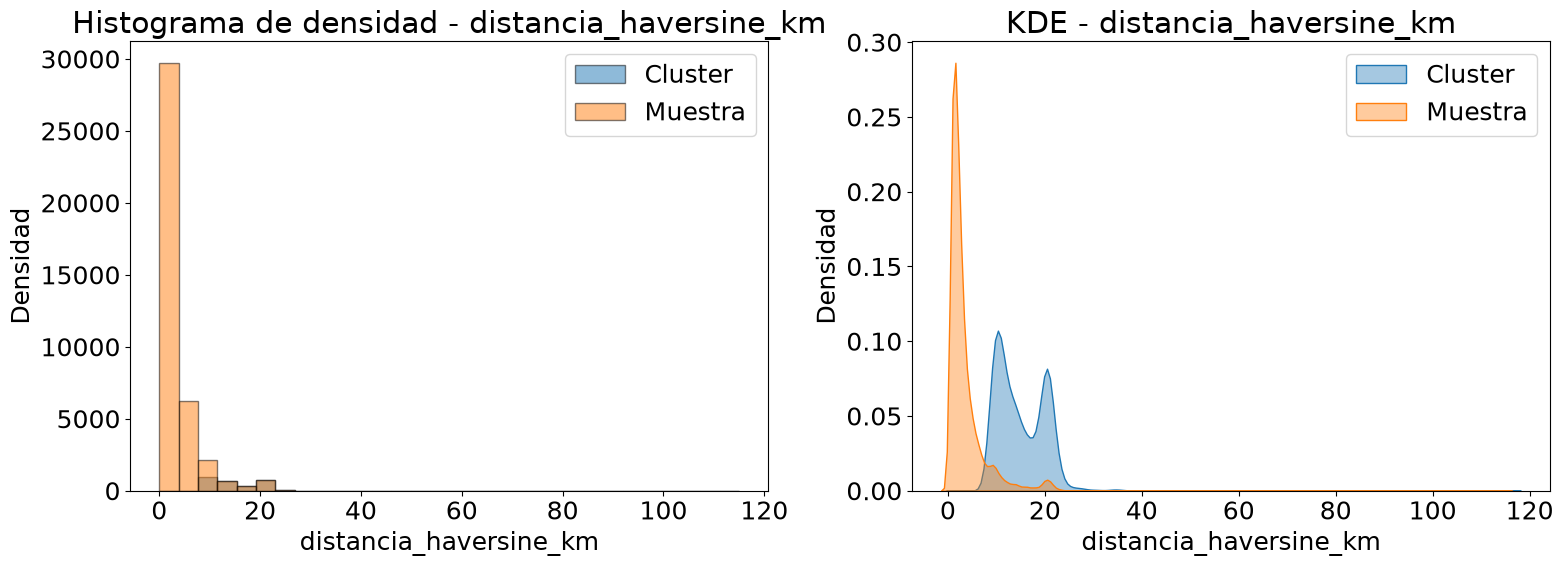

In [536]:
histograma_kde(df_km_c3,df,'distancia_haversine_km')

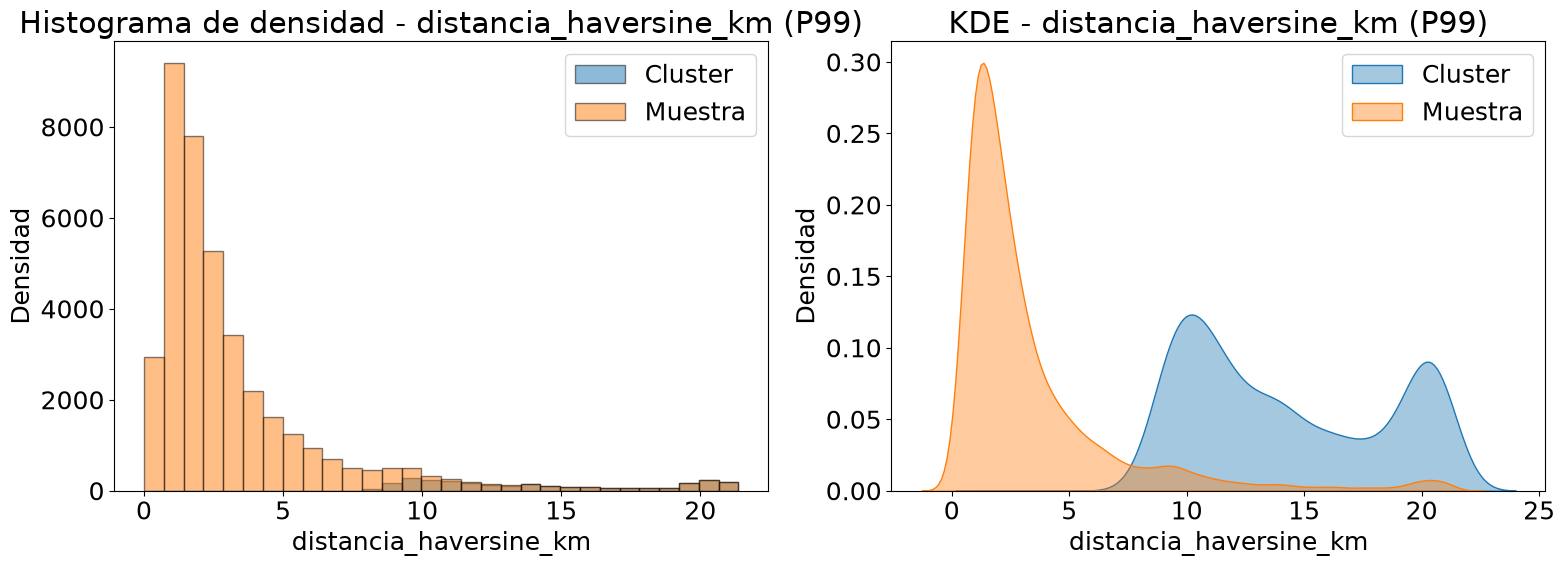

In [537]:
histograma_kde(df_km_c3,df,'distancia_haversine_km',30,99)

**Observaciones**
- Los viajes del cluster 3 selen poseer distancias mayores a los de la distribución de la muestra en general.

#### **velocidad_promedio_kmh**

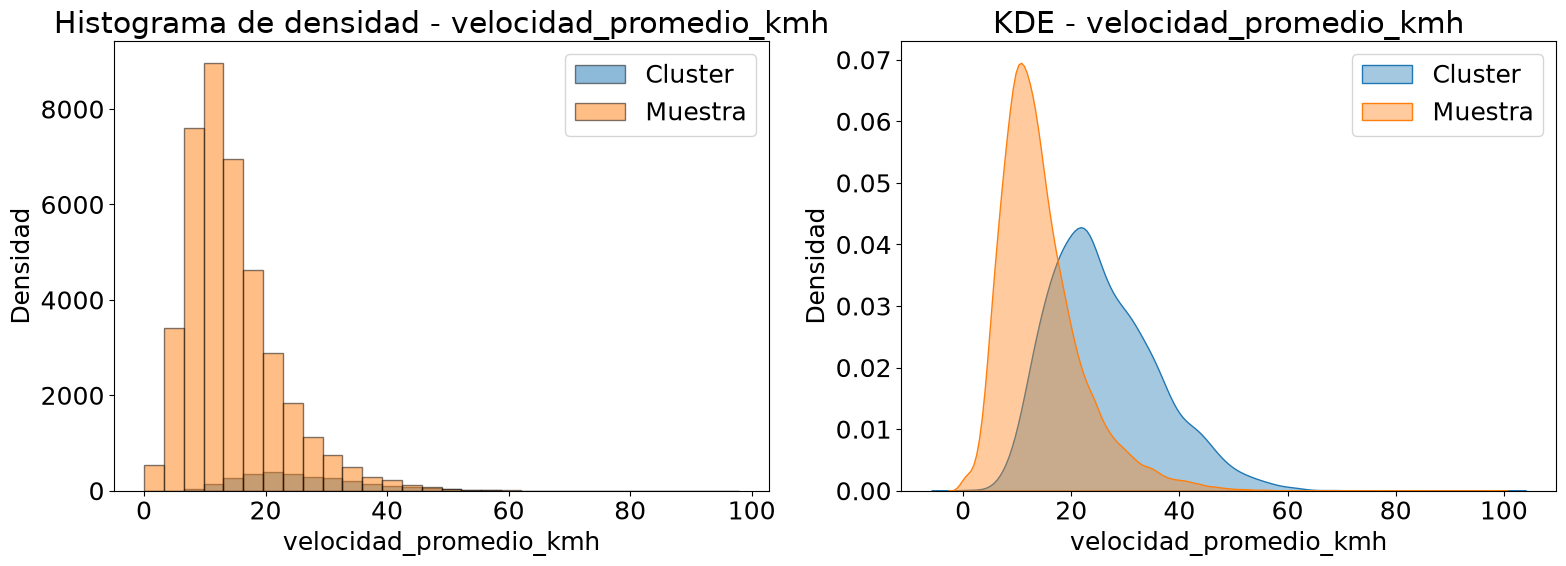

In [538]:
histograma_kde(df_km_c3,df,'velocidad_promedio_kmh')

**Observaciones**
- La concentración de la velocidad promedio de los viajes del cluster 3 es más alta en valores promedio de velocidad elevados en contraste a la distribución de la muestra.

#### **trip_duration**

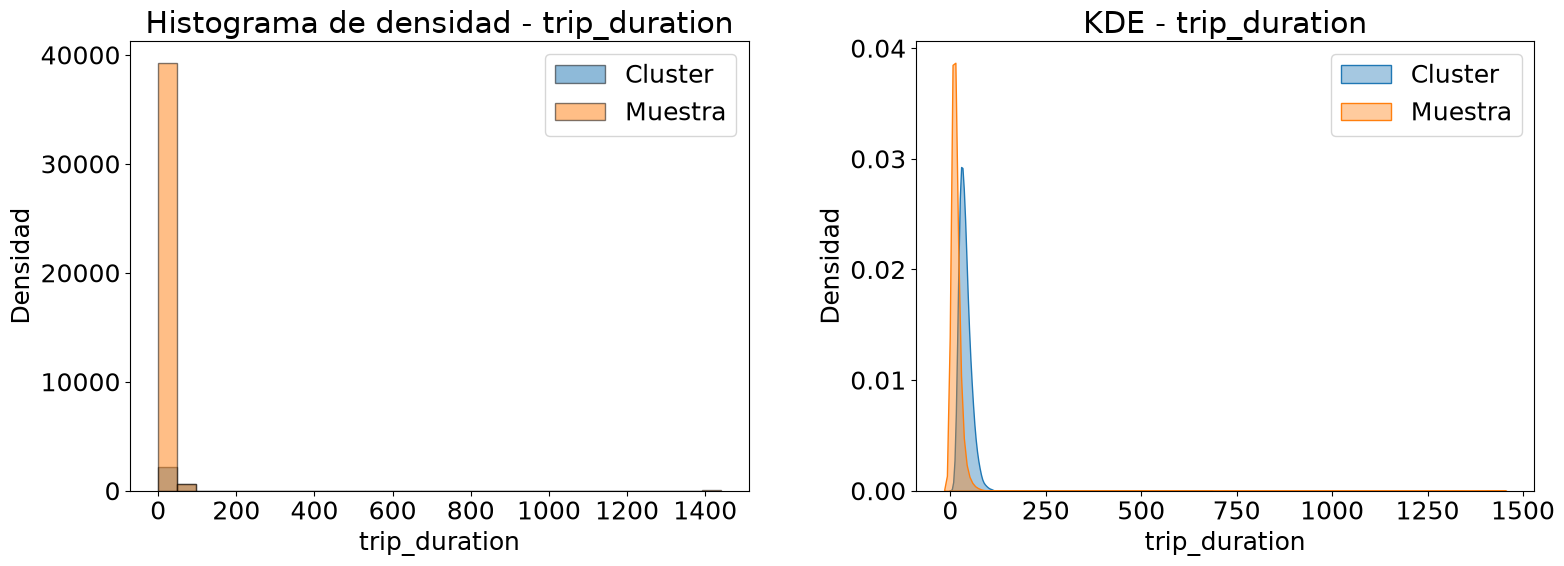

In [539]:
histograma_kde(df_km_c3,df,'trip_duration')

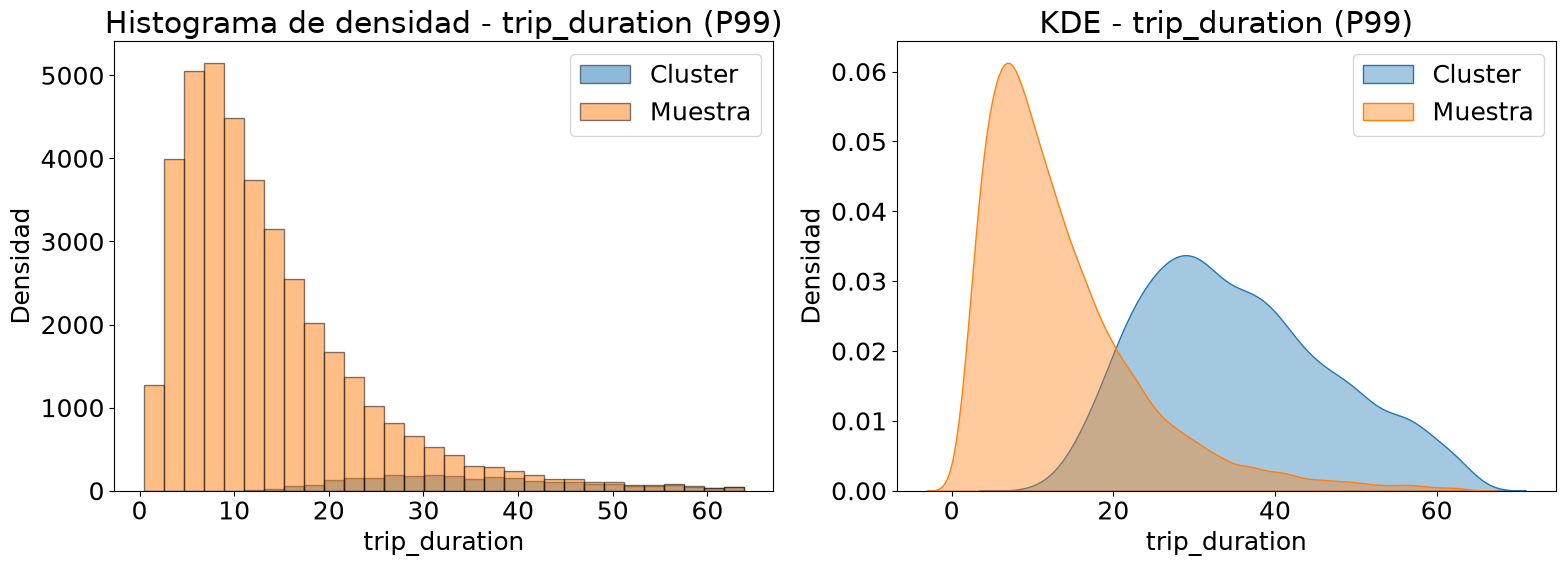

In [540]:
histograma_kde(df_km_c3,df,'trip_duration',30,99)

**Observaciones**
- La concentración de viajes con alta duración es mayor en los viajes del cluster 3 en contraste con los de la muestra en general.

# **3. DBSCAN**

## **3.1 Búsqueda Hiperparámetros**

In [541]:
output_dir = "../output/role_2"
output_file = os.path.join(output_dir, "dbscan_results.csv")

if os.path.exists(output_file):

    resultados_dbscan = pd.read_csv(output_file)

    print(f"El archivo ya existe. Resultados cargados desde: {output_file}")

else:

    os.makedirs(output_dir, exist_ok=True)

    eps_values = np.arange(0.3, 1.1, 0.1)
    min_samples_values = [5, 10, 15, 20]

    resultados_dbscan = []

    for min_samples in min_samples_values:

        for eps in eps_values:

            dbscan = DBSCAN(
                eps=eps,
                min_samples=min_samples
            )

            labels = dbscan.fit_predict(X_scaled)

            n_clusters = len(set(labels)) - (
                1 if -1 in labels else 0
            )

            porcentaje_ruido = (
                labels == -1
            ).mean() * 100

            if n_clusters >= 2:

                mask = labels != -1

                X_eval = X_scaled[mask]
                labels_eval = labels[mask]

                silhouette = silhouette_score(
                    X_eval,
                    labels_eval
                )

                davies_bouldin = davies_bouldin_score(
                    X_eval,
                    labels_eval
                )

                calinski_harabasz = calinski_harabasz_score(
                    X_eval,
                    labels_eval
                )

            else:

                silhouette = np.nan
                davies_bouldin = np.nan
                calinski_harabasz = np.nan

            resultados_dbscan.append({
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "ruido_%": porcentaje_ruido,
                "silhouette": silhouette,
                "davies_bouldin": davies_bouldin,
                "calinski_harabasz": calinski_harabasz
            })

    resultados_dbscan = pd.DataFrame(resultados_dbscan)

    resultados_dbscan.to_csv(
        output_file,
        index=False
    )

    print(f"Resultados calculados y guardados en: {output_file}")

Resultados calculados y guardados en: ../output/role_2/dbscan_results.csv


## **3.2 Visualización Métricas**

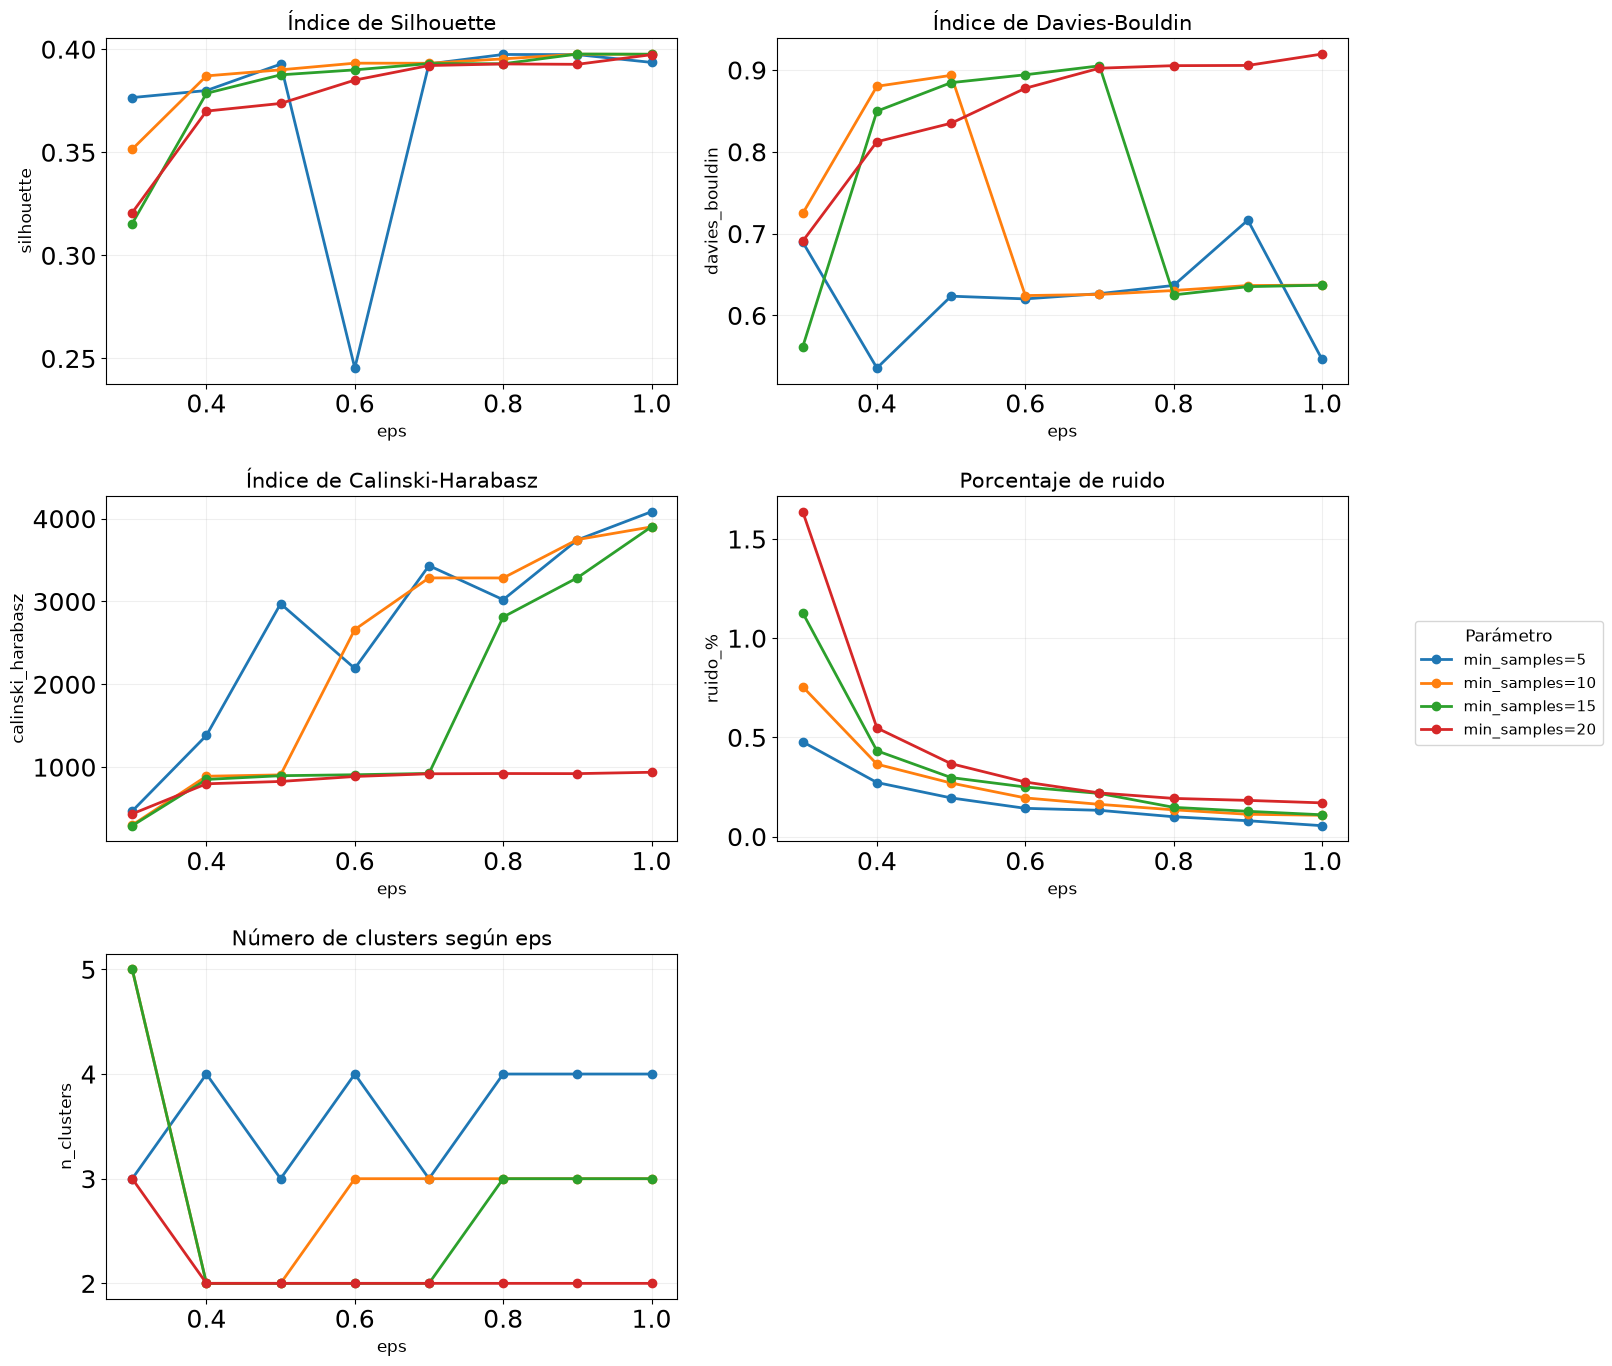

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

min_samples_values = resultados_dbscan["min_samples"].unique()

metricas = [
    ("silhouette", "Índice de Silhouette"),
    ("davies_bouldin", "Índice de Davies-Bouldin"),
    ("calinski_harabasz", "Índice de Calinski-Harabasz"),
    ("ruido_%", "Porcentaje de ruido"),
    ("n_clusters", "Número de clusters según eps")
]

for ax, (metrica, titulo) in zip(axes.flat, metricas):

    for min_samples in min_samples_values:

        datos = resultados_dbscan[
            resultados_dbscan["min_samples"] == min_samples
        ].sort_values("eps")

        ax.plot(
            datos["eps"],
            datos[metrica],
            marker="o",
            linewidth=2,
            label=f"min_samples={min_samples}"
        )

    ax.set_title(titulo, fontsize=15)
    ax.set_xlabel("eps", fontsize=12)
    ax.set_ylabel(metrica, fontsize=12)
    ax.grid(alpha=0.2)

# Ocultar el sexto espacio
axes[2, 1].axis("off")

# Leyenda única
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.89, 0.5),
    title="Parámetro",
    fontsize=11,
    title_fontsize=12
)

# Espacio para la leyenda
plt.tight_layout(rect=[0, 0, 0.87, 1])

plt.show()

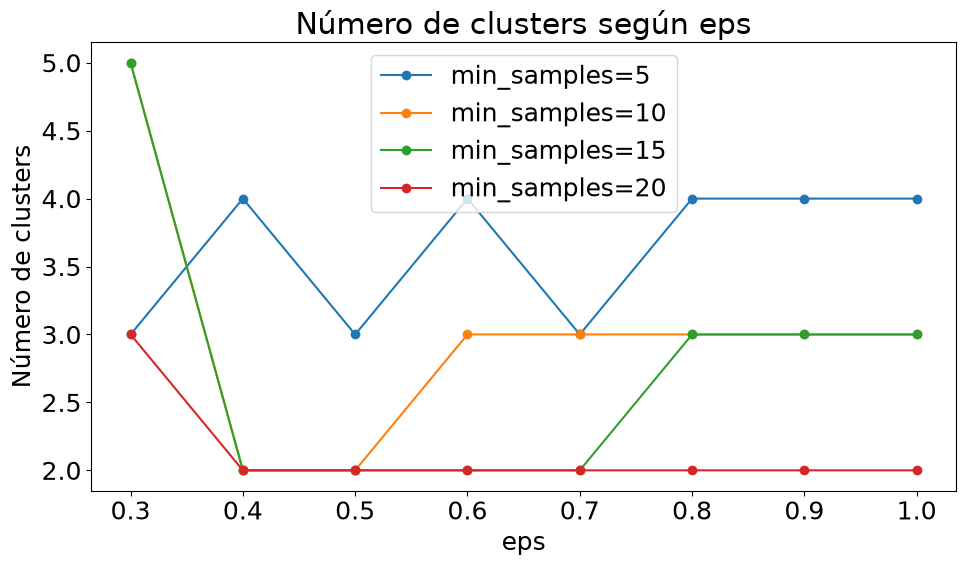

In [548]:
plt.figure(figsize=(10, 6))

for min_samples in resultados_dbscan["min_samples"].unique():
    datos = resultados_dbscan[
        resultados_dbscan["min_samples"] == min_samples
    ]

    plt.plot(
        datos["eps"],
        datos["n_clusters"],
        marker="o",
        label=f"min_samples={min_samples}"
    )

plt.xlabel("eps")
plt.ylabel("Número de clusters")
plt.title("Número de clusters según eps")
plt.legend()
plt.tight_layout()
plt.show()